In [1]:
import numpy as np

In [2]:
rng = np.random.default_rng(42)

In [3]:
runs = 1000
N = 1000
ks = np.arange(1, N + 1, 1, dtype=int)
ps = np.linspace(0.0, 1.0, 11, endpoint=True)

In [4]:
from tqdm import tqdm

In [5]:
ts = []
for k in tqdm(ks):
    for p in ps:
        for r in range(runs):
            # Fase 1: seleciona de uma hipergeométrica com nbad = (1 - p)*(N - k)
            ngood = k
            nbad = int(np.floor((1.0 - p) * (N - k)))
            d = rng.hypergeometric(ngood=ngood, nbad=nbad, nsample=ngood)

            # Fase 2: seleciona de uma hipergeométrica com ngood = p * (k - d)
            ngood = int(np.floor(p * (k - d)))
            nbad = N - k
            m = rng.hypergeometric(ngood=ngood, nbad=nbad, nsample=ngood)

            t = d + m
            ts.append((k, p, r, t))

100%|██████████| 1000/1000 [00:45<00:00, 21.91it/s]


In [6]:
import pandas as pd

cols = ["k", "p", "r", "t"]
df_ts = pd.DataFrame(ts, columns=cols)

In [7]:
df_ts

,k,p,r,t
0,1,0.0,0,0
1,1,0.0,1,0
2,1,0.0,2,0
3,1,0.0,3,0
4,1,0.0,4,0
...,...,...,...,...
10999995,1000,1.0,995,1000
10999996,1000,1.0,996,1000
10999997,1000,1.0,997,1000
10999998,1000,1.0,998,1000


In [8]:
nngs = df_ts["t"] / (2.0 * df_ts["k"] - df_ts["t"])

In [9]:
df_nngs = df_ts.drop(columns=["t"])
df_nngs["nngs"] = nngs

In [10]:
df_nngs_mean = df_nngs.groupby(["k", "p"])["nngs"].mean().unstack()

In [11]:
df_nngs_mean.iloc[:10, :]

p,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0
k,,,,,,,,,,,
1,0.000000,0.001000,0.002000,0.001000,0.000000,0.003000,0.005000,0.001000,0.007000,0.010000,1.0
2,0.003333,0.003000,0.002667,0.001333,0.003333,0.003333,0.003333,0.002667,0.006333,0.010333,1.0
3,0.001800,0.002700,0.001200,0.001600,0.002600,0.005500,0.004600,0.006400,0.009100,0.016700,1.0
4,0.001571,0.003286,0.002857,0.003571,0.004571,0.004857,0.007286,0.006190,0.012952,0.022619,1.0
5,0.002444,0.002556,0.003444,0.003111,0.005333,0.005472,0.009556,0.011028,0.016583,0.029917,1.0
6,0.003545,0.003545,0.003364,0.003927,0.006855,0.008418,0.008836,0.012509,0.018309,0.034115,1.0
7,0.004462,0.003718,0.005526,0.005231,0.005628,0.007821,0.009462,0.013487,0.020372,0.039113,1.0
8,0.004267,0.004886,0.004629,0.007181,0.007095,0.009590,0.010371,0.014276,0.024116,0.042167,1.0
9,0.005022,0.004941,0.007206,0.006676,0.008522,0.010907,0.015131,0.018584,0.026754,0.048002,1.0


In [12]:
nngs_lower_bound = ks / (2*N - ks)

In [13]:
df_nngs_mean_normalized = (df_nngs_mean - nngs_lower_bound[:, np.newaxis]) / (1.0 - nngs_lower_bound[:, np.newaxis])

In [14]:
import matplotlib.pyplot as plt

In [15]:
k_max_plot = 30

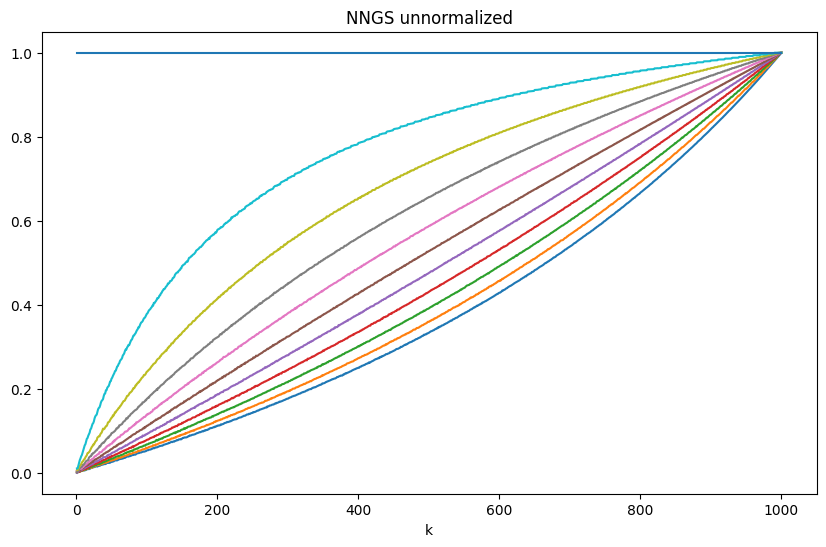

In [16]:
plt.figure(figsize=(10, 6))
df_nngs_mean.plot(ax=plt.gca(), legend=False, title="NNGS unnormalized")
plt.show()

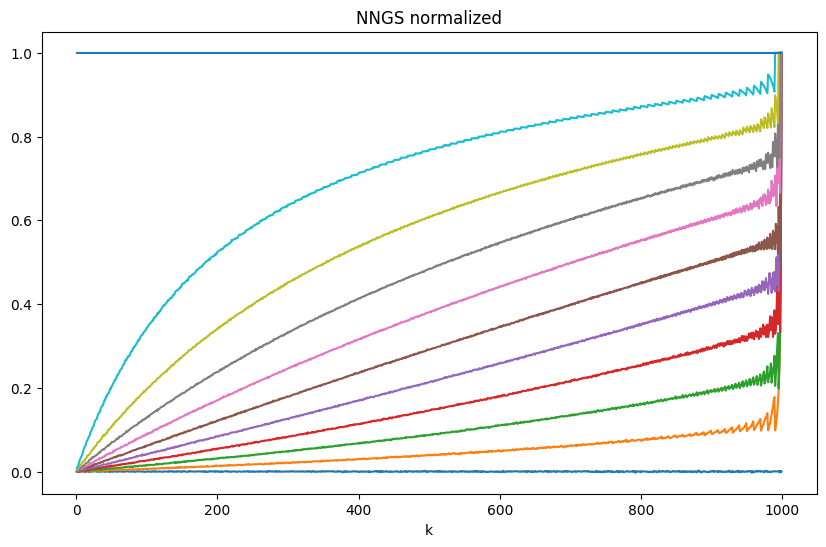

In [17]:
plt.figure(figsize=(10, 6))
df_nngs_mean_normalized.plot(ax=plt.gca(), legend=False, title="NNGS normalized")
plt.show()